In [ ]:
import sys
import scipy
import airportsdata
import numpy as np
from openap.kinematic import WRAP
from openap import Thrust
from tqdm.notebook import tqdm
from openap import Drag
import math
from openap import prop
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'airportsdata'

In [2]:
sys.executable

'/home/sa931773/miniconda3/envs/aeroplane/bin/python'

In [3]:
# Physical constants
g = scipy.constants.g
Rspecific = 287.0528
# Related constants
mass_of_person = 86.1826

In [4]:
airport_codes = [
    "EBBR",
    "EDDF",
    "EDDL",
    "EDDM",
    "EGKK",
    "EGLC",
    "EGLL",
    "EHAM",
    "EIDW",
    "EKCH",
    "ENGM",
    "ESSA",
    "LEBL",
    "LEMD",
    "LEPA",
    "LESO",
    "LFPG",
    "LFPO",
    "LGAV",
    "LGHI",
    "LICG",
    "LIMC",
    "LIRF",
    "LIRA",
    "LOWW",
    "LPPT",
    "LSZH",
    "LTAI",
    "LTFJ",
    "LTFM",
]

In [5]:
airports = airportsdata.load()  # key is the ICAO identifier (the default)

In [6]:
airport_names = []
airport_latitudes = []
airport_longitudes = []

airports = airportsdata.load()

for i in range(len(airport_codes)):

    airport_names.append(airports[airport_codes[i]]["name"])
    airport_latitudes.append(airports[airport_codes[i]]["lat"])
    airport_longitudes.append(airports[airport_codes[i]]["lon"])

In [7]:
"""
Parameter cell for papermill
"""

airport_code = "EGLL"
model = "UKESM1-0-LL"
ac = "a320"
months = "JJA"  # use 'all_months' for all months, otherwise DJF, MAM, JJA, SON.
batch = False
mass_calc = False
_2030 = False

# Calculate mass restrictions for airport_codes_with_mass_adjustments = ['EGLC','LGHI','LICG','LIRA','LESO']

Hp = airports[airport_code]["elevation"]
print(
    "elevation of "
    + airport_names[airport_codes.index(airport_code)]
    + " = "
    + str(Hp)
    + " feet."
)

elevation of London Heathrow Airport = 83.0 feet.


In [8]:
airport_code
airports[airport_code]
airports[airport_code]["name"]

'London Heathrow Airport'

# Take-off distance required (TODR) calculation

# Ideal gas law

$$P=\rho R_{\mathrm{specific}} T$$

$R_{\mathrm{specific}}$ for dry air is 287.0528 $\mathrm{J \cdot kg^{-1} \cdot K^{-1}}$, https://en.wikipedia.org/wiki/International_Standard_Atmosphere#Description.

Therefore $$\rho=\frac{P}{R_{\mathrm{specific}} T}$$


In [9]:
# From Gratton et al. again.
theta = 0
phi = 7.7
mu = 0.02

In [10]:
# A320 values are from supplementary information #2 of Gratton et al. (2020).

ms_groundTruth_dict = {}
ms_groundTruth_dict["a320"] = np.array(
    [61235, 63503, 65771, 68039, 70307, 72575, 74843, 77111, 79379]
)
ms_groundTruth = ms_groundTruth_dict[ac]

TODR_manufacturer_dict = {}
TODR_manufacturer_dict["a320"] = np.array(
    [1233, 1344, 1455, 1579, 1689, 1798, 1946, 2134, 2362]
)
TODR_manufacturer = TODR_manufacturer_dict[ac]

TODR_gratton = np.array([1243, 1347, 1456, 1571, 1694, 1823, 1959, 2103, 2256])

In [11]:
wrap = WRAP(ac=ac)
props = prop.aircraft(ac)
S = props["wing"]["area"]
mmax = props["mtow"]

if ac == "a320":
    eng = "V2500-A1"
else:
    eng = None  # Default value

thrust = Thrust(ac=ac, eng=eng)

In [12]:
# rho = 1.225 is the density at standard atmosphere, https://en.wikipedia.org/wiki/Density_of_air.
# m = 61325 is the lowest mass in Table 1 of Gratton et al. (2020) supplementary material #2.
deltav = 0.01
defaultm = ms_groundTruth[0]
defaultrho = 1.225
defaultCL = 1
tass = [
    wrap.takeoff_speed()["minimum"],
    wrap.takeoff_speed()["default"],
    wrap.takeoff_speed()["maximum"],
]

In [13]:
tass

[74.5, 85.3, 96.0]

In [14]:
def TODR(
    m=defaultm,
    rho=defaultrho,
    CL=defaultCL,
    deltav=deltav,
    Hp=Hp,
    vmax=150,
    printHp=False,
    use_openap=True,
    headwind=0,
    tas=tass[1],  # <--- optimum take-off speed.
):

    if printHp:
        print("Hp = " + str(Hp))

    ground_speed = np.arange(0, vmax, step=deltav)

    myDict = {}

    if use_openap:

        CD0 = (
            Drag(ac=ac).aircraft["drag"]["cd0"] + Drag(ac=ac).aircraft["drag"]["gears"]
        )
        k = Drag(ac=ac).aircraft["drag"]["k"]

        T = thrust.takeoff(tas=tas, alt=Hp)  # data/wrap/a320.txt

        myDict["T"] = T

    else:  # BADA 3

        CT1 = 0.14231e06
        CT2 = 0.51680e05
        CT3 = 0.56809e-10
        CD0 = 0.33000e-01
        k = 0.41000e-01

        myDict["T"] = CT1 * (1 - Hp / CT2 + CT3 * (Hp**2))

    myDict["L"] = 0.5 * rho * ((ground_speed + headwind) ** 2) * S * CL

    CD = CD0 + k * (CL**2)
    myDict["D"] = 0.5 * rho * ((ground_speed + headwind) ** 2) * S * CD

    myDict["W"] = m * g

    myDict["a"] = (
        myDict["T"]  # Thrust
        - myDict["D"]  # Drag
        - mu
        * (m * g * math.cos(theta * scipy.constants.pi / 180) - myDict["L"])  # Friction
        - m * g * math.sin(theta * scipy.constants.pi / 180)  # Weight * sin(theta)
    ) / m

    # Index of VTAS array when | L - W | is minimised, i.e. at takeoff.
    myDict["index"] = np.argmin(abs(myDict["L"] - myDict["W"]))

    deltax = []

    for i in np.arange(1, len(ground_speed[0 : (myDict["index"] + 2)])):
        deltax.append(
            np.mean([ground_speed[i], ground_speed[i - 1]])
            * deltav
            / np.mean([myDict["a"][i], myDict["a"][i - 1]])
        )

    myDict["deltax"] = deltax

    myDict["x"] = np.cumsum(deltax)[myDict["index"]]

    myDict["VTAS"] = ground_speed + headwind
    myDict["deltav"] = deltav

    myDict["XA"] = 0.3048 * (35 / math.tan(phi * scipy.constants.pi / 180))

    myDict["_TODR"] = (myDict["x"] + myDict["XA"]) * 1.15

    return myDict

In [15]:
if TODR()["_TODR"] == TODR(Hp=Hp)["_TODR"]:

    print("\u2705")
else:

    print("\u2717")

✅


# Look at what value of CL gives best agreement at sea level (Hp = 0) as a function of mass. 

  0%|          | 0/3 [00:00<?, ?it/s]

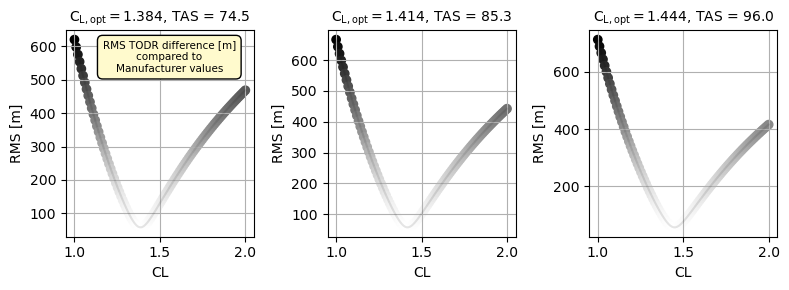

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=3)

fig.set_figheight(3)
fig.set_figwidth(8)

CLopts = []

for k in tqdm(range(3)):

    RMSs = []

    CLs = np.linspace(1, 2, 100)

    for j in range(len(CLs)):

        TODR_as_function_of_mass = []

        for i in range(len(ms_groundTruth)):
            TODR_as_function_of_mass.append(
                TODR(
                    m=ms_groundTruth[i], CL=CLs[j], Hp=0, use_openap=True, tas=tass[k]
                )["_TODR"]
            )

        TODR_as_function_of_mass = np.array(TODR_as_function_of_mass)

        RMSs.append(
            np.sqrt(np.mean((TODR_as_function_of_mass - TODR_manufacturer) ** 2))
        )

    ############################
    CLopt = CLs[np.argmin(RMSs)]
    CLopts.append(CLopt)
    ############################

    axes.flatten()[k].scatter(CLs, RMSs, marker="o", c=RMSs, cmap="Greys")
    axes.flatten()[k].plot(CLs, RMSs, "k-", alpha=0.1)

    axes.flatten()[k].set_xlabel("CL")
    axes.flatten()[k].set_ylabel("RMS [m]")
    axes.flatten()[k].grid()
    axes.flatten()[k].set_title(
        r"$\mathrm{C_{L,opt} = }$" + str(CLopt.round(3)) + ", TAS = " + str(tass[k]),
        fontsize=10,
    )
    if k == 0:
        axes.flatten()[k].text(
            0.55,
            0.95,
            "RMS TODR difference [m]\ncompared to\nManufacturer values",
            transform=axes.flatten()[k].transAxes,
            color="black",
            fontsize=7.5,
            va="top",
            ha="center",
            bbox=dict(facecolor="lemonchiffon", boxstyle="round,pad=0.5"),
        )

plt.tight_layout()

plt.show();